In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/janithwanni/old-faithful/faithful.csv


In [7]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/janithwanni/old-faithful/faithful.csv",index_col=0)
x = df[["eruptions", "waiting"]].values

print(df.head())

   eruptions  waiting
1      3.600       79
2      1.800       54
3      3.333       74
4      2.283       62
5      4.533       85


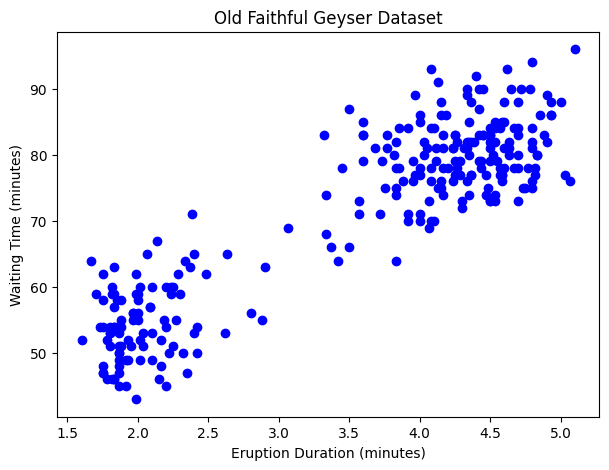

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(x[:,0], x[:,1], color='blue')
plt.title("Old Faithful Geyser Dataset")
plt.xlabel("Eruption Duration (minutes)")
plt.ylabel("Waiting Time (minutes)")
plt.show()

In [12]:
wcss = []
from sklearn.cluster import KMeans
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

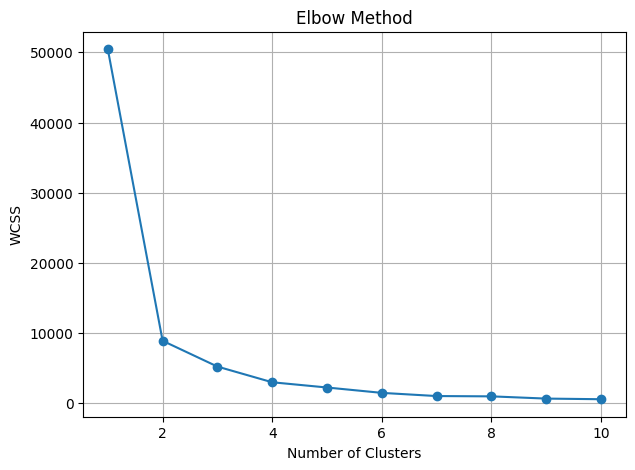

In [13]:
plt.figure(figsize=(7,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [14]:
kmeans = KMeans(
    n_clusters=2,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(x)

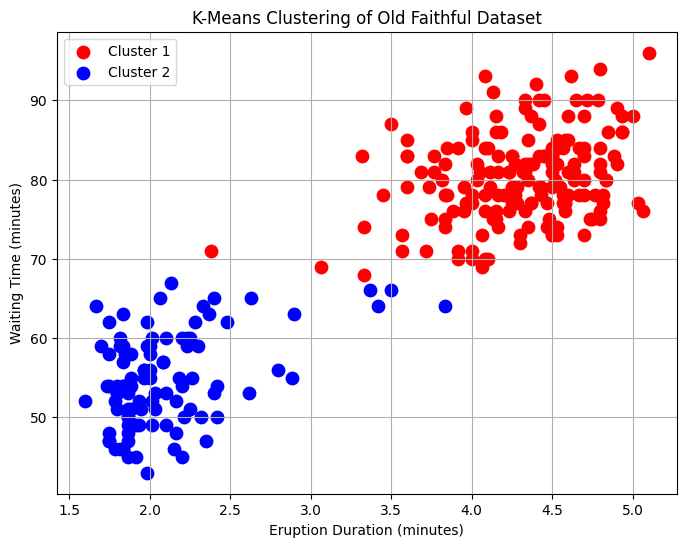

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    x[y_kmeans == 0, 0],
    x[y_kmeans == 0, 1],
    s=80,
    c='red',
    label='Cluster 1'
)

plt.scatter(
    x[y_kmeans == 1, 0],
    x[y_kmeans == 1, 1],
    s=80,
    c='blue',
    label='Cluster 2'
)

plt.title("K-Means Clustering of Old Faithful Dataset")
plt.xlabel("Eruption Duration (minutes)")
plt.ylabel("Waiting Time (minutes)")
plt.legend()
plt.grid(True)

plt.show()

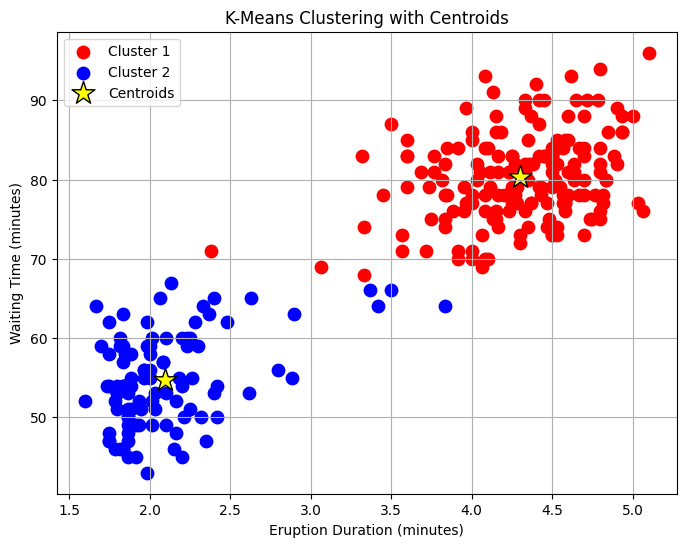

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    x[y_kmeans == 0, 0],
    x[y_kmeans == 0, 1],
    s=80,
    c='red',
    label='Cluster 1'
)

plt.scatter(
    x[y_kmeans == 1, 0],
    x[y_kmeans == 1, 1],
    s=80,
    c='blue',
    label='Cluster 2'
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='yellow',
    marker='*',
    edgecolors='black',
    label='Centroids'
)

plt.title("K-Means Clustering with Centroids")
plt.xlabel("Eruption Duration (minutes)")
plt.ylabel("Waiting Time (minutes)")
plt.legend()
plt.grid(True)

plt.show()